In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Step 1 - Loading SPY and daily returns

In [2]:
# Load your 3 WSJ CSV files from data folder
# Replace 'SPY.csv', 'QQQ.csv', 'IWM.csv' with your ACTUAL filenames
spy_data = pd.read_csv('/Users/Sinthu/Desktop/(Quant Trading Project)/data/spy.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')
qqq_data = pd.read_csv('/Users/Sinthu/Desktop/(Quant Trading Project)/data/qqq.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')
iwm_data = pd.read_csv('/Users/Sinthu/Desktop/(Quant Trading Project)/data/iwm.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')

#Clean up column names for each data set (they have unneccasary space at the beginning of the column
spy_data.columns = spy_data.columns.str.strip()
qqq_data.columns = qqq_data.columns.str.strip()
iwm_data.columns = iwm_data.columns.str.strip()

#Making sure dates start with oldest to newest
spy_data.sort_index(inplace=True)
qqq_data.sort_index(inplace=True)
iwm_data.sort_index(inplace=True)

#Making sure dates start with oldest to newest
spy_data.sort_index(inplace=True)

In [3]:
# Extract adjusted close prices and combine
spy = pd.DataFrame({'Adj_Close': spy_data['Close']  })

print("Combined prices shape:", spy.shape)
print("\nFirst 5 rows:")
spy.head()

Combined prices shape: (8341, 1)

First 5 rows:


,Adj_Close
Date,
1993-01-29,43.9375
1993-02-01,44.2500
1993-02-02,44.3438
1993-02-03,44.8125
1993-02-04,45.0000


In [4]:
# Simple and log returns
spy["simple_return"] = spy["Adj_Close"].pct_change()
spy["log_return"] = np.log(spy["Adj_Close"] / spy["Adj_Close"].shift(1))
spy = spy.dropna(subset=["simple_return", "log_return"])
spy.head()

,Adj_Close,simple_return,log_return
Date,,,
1993-02-01,44.2500,0.007112,0.007087
1993-02-02,44.3438,0.002120,0.002118
1993-02-03,44.8125,0.010570,0.010514
1993-02-04,45.0000,0.004184,0.004175
1993-02-05,44.9688,-0.000693,-0.000694


Step 2 - Rebuild MA signal with correct shift

In [5]:
short_window = 50
long_window = 200

spy["ma_short"] = spy["Adj_Close"].rolling(window=short_window).mean()
spy["ma_long"] = spy["Adj_Close"].rolling(window=long_window).mean()

In [6]:
#Raw and shifted signals
spy["signal_raw"] = 0
spy.loc[spy["ma_short"] > spy["ma_long"], "signal_raw"] = 1

# Shift so that today’s position uses yesterday’s signal (avoid look-ahead)
spy["signal"] = spy["signal_raw"].shift(1)
spy = spy.dropna(subset=["signal"])

spy[["Adj_Close", "ma_short", "ma_long", "signal_raw", "signal"]].head(1000)

,Adj_Close,ma_short,ma_long,signal_raw,signal
Date,,,,,
1993-02-02,44.3438,NaN,NaN,0,0.0
1993-02-03,44.8125,NaN,NaN,0,0.0
1993-02-04,45.0000,NaN,NaN,0,0.0
1993-02-05,44.9688,NaN,NaN,0,0.0
1993-02-08,44.9688,NaN,NaN,0,0.0
...,...,...,...,...,...
1997-01-09,75.3125,74.057206,68.478687,1,1.0
1997-01-10,76.1250,74.171580,68.535562,1,1.0
1997-01-13,76.0156,74.288454,68.590641,1,1.0


Step 3 - Define a simple backtest function

We'll compare:
- Buy and Hold: always invested (is position 1)
- MA strategy: daily position = signal

In [7]:
def backtest_from_returns(returns: pd.Series, position: pd.Series, name="strategy"):
    """
    returns: daily simple returns (e.g. spy['simple_return'])
    position: daily position (0 or 1) aligned with returns index
    """
    aligned_returns = returns.loc[position.index]  #makes sure returns & positions use the same dates
    strat_daily_ret = aligned_returns * position   #Position 1 you earn market return and position 0 nothing

    equity = (1 + strat_daily_ret).cumprod()      #Shows how £1 grows over time
    cumulative_return = equity.iloc[-1] - 1       #Final value minus 1

    daily_mean = strat_daily_ret.mean()           #Average daily return
    daily_vol = strat_daily_ret.std()             #Daily volatility
    if daily_vol != 0:
        sharpe_like = (daily_mean * 252) / (daily_vol * np.sqrt(252))     #Sharpe like ratio = annual return/annual volatility
    else:
        sharpe_like = np.nan

    max_dd = (equity / equity.cummax() - 1).min()    #Worst loss from peak (Maximum drawdown)

    summary = {
        "name": name,
        "cumulative_return": cumulative_return,
        "annual_return": daily_mean * 252,
        "annual_vol": daily_vol * np.sqrt(252),
        "sharpe_like": sharpe_like,
        "max_drawdown": max_dd
    }
    return strat_daily_ret, equity, summary       # 1 - Daily returns, 2 - Growth of £1 over time and 3 - Performance metrics

The function above it converts signals (0/1 decisions) into performance (returns, risk and drawdowns). Builds a strategy equity curve

It is important as it allows me evaulate strategies:
- Does it make money? RETURN
- Is it risky? VOLATILITY
- Is it worth it? SHARPE
- How painful is it? DRAWDOWN

Sharpe formula simplifies to: (daily mean/ daily vol) x sqrt(252)

Step 4 - Run buy and hold vs MA Strategy

In [8]:
# Position = 1 every day
bh_position = pd.Series(1.0, index=spy.index)

bh_ret, bh_equity, bh_summary = backtest_from_returns(
    spy["simple_return"], bh_position, name="Buy & Hold"
)
bh_summary

{'name': 'Buy & Hold',
 'cumulative_return': np.float64(13.967005649717484),
 'annual_return': np.float64(0.09912757407151826),
 'annual_vol': np.float64(0.1862100798665026),
 'sharpe_like': np.float64(0.532342685973738),
 'max_drawdown': -0.5647367075664627}

Buy and hold strategy:
- This strategy works by investing £1 and always keeping it in the market - never touching it
- Takes all markets UP and DOWNs - to see what happens

MA strategy:
- Invest only when ma short > ma long (moves in and out)
- Otherwise sits in cash

What we are looking for?
- We set 'Buy and hold strategy' as the baseline/ benchmark
- Compare it to 'MA strategy' for: Drawdowns, Return and Sharpe
   - Good Strategy would have: lower Drawdowns, similar Return and higher Sharpe
   - Bad Strategy would have: Lower return, similar or worse return

In [9]:
ma_position = spy["signal"]  # 0 or 1

ma_ret, ma_equity, ma_summary = backtest_from_returns(
    spy["simple_return"], ma_position, name="MA 50/200"
)
ma_summary

{'name': 'MA 50/200',
 'cumulative_return': np.float64(10.989138338205157),
 'annual_return': np.float64(0.08415336781504715),
 'annual_vol': np.float64(0.1345617872914205),
 'sharpe_like': np.float64(0.6253883030908038),
 'max_drawdown': -0.34104746704498456}

Comparing Drawdowns, Cumulative/ Annualised Return and Sharpe can notice 'MA' is a better strategy than 'Buy and hold strategy' 

Step 5 - Compare metrics in a small table

In [10]:
#Summary Data frame
summary_df = pd.DataFrame([bh_summary, ma_summary]).set_index("name")
summary_df.map(lambda x: f"{x:.2%}" if isinstance(x, float) else x)

,cumulative_return,annual_return,annual_vol,sharpe_like,max_drawdown
name,,,,,
Buy & Hold,1396.70%,9.91%,18.62%,53.23%,-56.47%
MA 50/200,1098.91%,8.42%,13.46%,62.54%,-34.10%


In [11]:
#To see the raw numbers of the data frame
summary_df

,cumulative_return,annual_return,annual_vol,sharpe_like,max_drawdown
name,,,,,
Buy & Hold,13.967006,0.099128,0.186210,0.532343,-0.564737
MA 50/200,10.989138,0.084153,0.134562,0.625388,-0.341047


Step 6 - Plot equity curves together

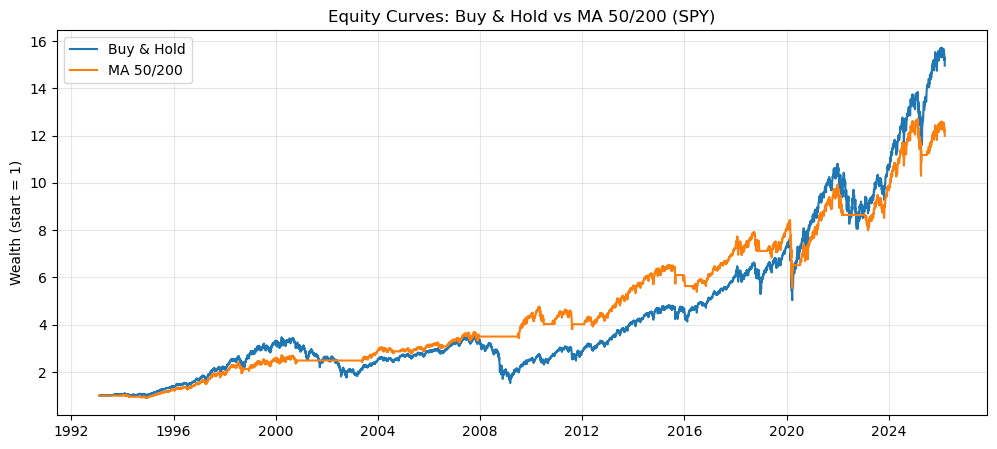

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(bh_equity.index, bh_equity, label="Buy & Hold", linewidth=1.5)
plt.plot(ma_equity.index, ma_equity, label="MA 50/200", linewidth=1.5)
plt.title("Equity Curves: Buy & Hold vs MA 50/200 (SPY)")
plt.ylabel("Wealth (start = 1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

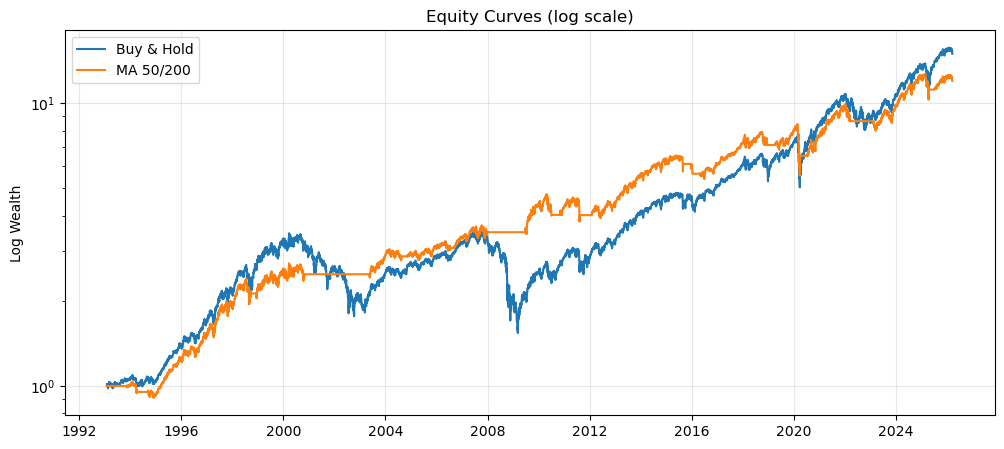

In [13]:
#Log scale view of the above equity curves plot
plt.figure(figsize=(12, 5))
plt.semilogy(bh_equity.index, bh_equity, label="Buy & Hold", linewidth=1.5)
plt.semilogy(ma_equity.index, ma_equity, label="MA 50/200", linewidth=1.5)
plt.title("Equity Curves (log scale)")
plt.ylabel("Log Wealth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Step 7 - Plot Daily Strategy Returns

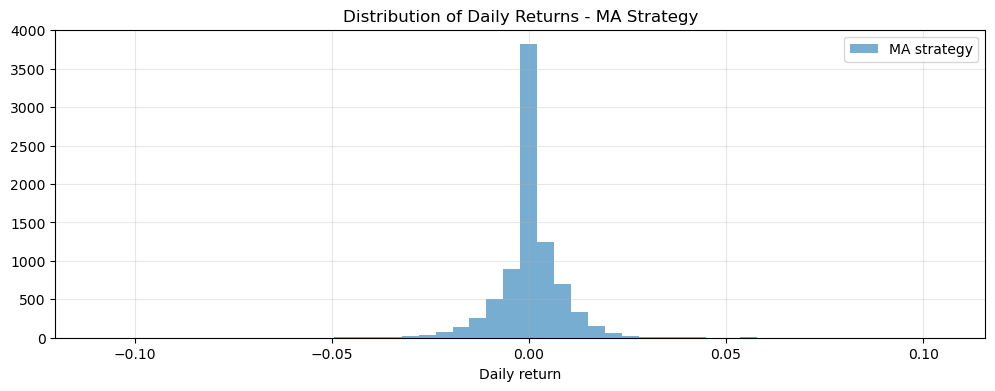

In [14]:
#Compare daily returns distributions
plt.figure(figsize=(12, 4))
ma_ret.hist(bins=50, alpha=0.6, label="MA strategy")
plt.title("Distribution of Daily Returns - MA Strategy")
plt.xlabel("Daily return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Easily visible from the distrubution of daily returns is in a normal distrubution form. To increase effectiveness mean needs to be more positive whilst keeping standard deviation low - that would create a good strategy.

## MA backtest – reflections

- Cumulative return (approx) for:
  - Buy & Hold: 1396.70%
  - MA 50/200:  1098.91%

- Max drawdown (approx):
  - Buy & Hold: -56.47%
  - MA 50/200:  -34.10%

- My interpretation:
  - MA 50/200 Strategy has the indications of a better strategy.
  - If considered REAL sharpe ratio, both strategies will categorise fairly low

- How the low number of switches (about 32) shows up in the equity curve:
  - Not massive jumps and it's noticeable that strategy didn't pre judge the crashes, as there's a noticeable drop.

- Anything confusing about the backtest function or the comparison:
  - Slightly how it works, need to understand how backtest full works